In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn')

import yfinance as yf
import sys

filePath ="/content/drive/MyDrive/Python/Library/"
# sys.path.append(filePath)  # change


# import mflabLibs as mflab
# from mlfinlab.microstructural_features.first_generation import get_roll_measure, get_corwin_schultz_estimator, get_roll_impact
# from mlfinlab.microstructural_features.entropy import get_shannon_entropy, get_plug_in_entropy, get_lempel_ziv_entropy, \
#     get_konto_entropy
# from mlfinlab.microstructural_features.encoding import encode_array
# from mlfinlab.microstructural_features.second_generation import get_bar_based_kyle_lambda, \
#     get_bar_based_amihud_lambda, get_bar_based_hasbrouck_lambda
# from mlfinlab.microstructural_features.misc import get_avg_tick_size, vwap
# from mlfinlab.microstructural_features.encoding import encode_tick_rule_array
# from mlfinlab.util import devadarsh
# from mlfinlab.util.misc import crop_data_frame_in_batches

#sys.path.append("/content/drive/MyDrive/2021/lecture/BData/")
#import myTA as mta
from statsmodels.tsa.stattools import adfuller



<ipython-input-1-d245dd3f190f>:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

<Figure size 1200x700 with 0 Axes>

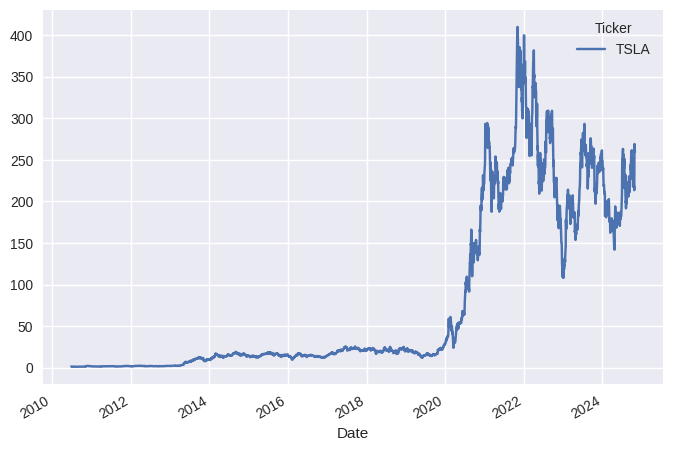

In [3]:
plt.figure(figsize=(12,7))
yf.download('TSLA').Close.plot()

[*********************100%***********************]  1 of 1 completed


<AxesSubplot: xlabel='Date'>

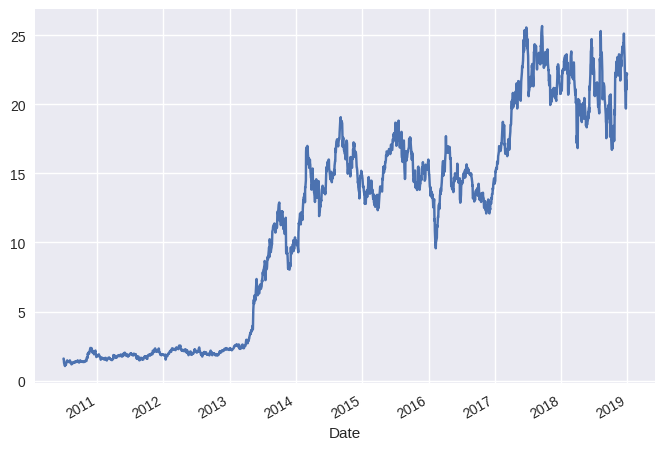

In [ ]:
yf.download('TSLA', end='2019-01-01').Close.plot()

In [5]:
se

Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2000-01-04 00:00:00+00:00,6110.0,6110.0,5660.0,6000.0,74195000
2000-01-05 00:00:00+00:00,5580.0,6060.0,5520.0,5800.0,74680000
2000-01-06 00:00:00+00:00,5620.0,5780.0,5580.0,5750.0,54390000
2000-01-07 00:00:00+00:00,5540.0,5670.0,5360.0,5560.0,40305000
2000-01-10 00:00:00+00:00,5770.0,5770.0,5580.0,5600.0,46880000
...,...,...,...,...,...
2024-10-23 00:00:00+00:00,59100.0,60000.0,57100.0,57500.0,27300780
2024-10-24 00:00:00+00:00,56600.0,58500.0,56600.0,58200.0,31499922


In [6]:
# download df

se = yf.download('005930.KS')  # SamSung Ele.
se = se.drop(['Adj Close'], axis=1)  # adj.close: 액면분할, 배당락 등을 고려한 종가
se.columns = ["close", 	"high", 	"low", 	"open", "volume"]

df = se.copy()

[*********************100%***********************]  1 of 1 completed


In [7]:
df['2008-09-17':'2008-09-19']
# df[cols], df.loc[index], df.iloc[int, int]


,close,high,low,open,volume
Date,,,,,
2008-09-17 00:00:00+00:00,10500.0,10740.0,10440.0,10700.0,29978550
2008-09-18 00:00:00+00:00,10340.0,10420.0,10080.0,10180.0,27650
2008-09-19 00:00:00+00:00,11160.0,11160.0,10640.0,10700.0,53205000


## Technical features

In [12]:
#sys.path.append('/media/chung/Elements/2022/class/')
import ta  # momentum, trend, volume, volatility
# see the last cell for python library used

In [13]:
#se_ori = se.copy()
df = se.copy()

In [ ]:
df.shape

(5736, 5)

In [14]:
len(df[df.volume ==  0])

127

In [15]:
#df.isna().sum()
df = df[~(df.volume == 0)]


<Axes: xlabel='Date'>

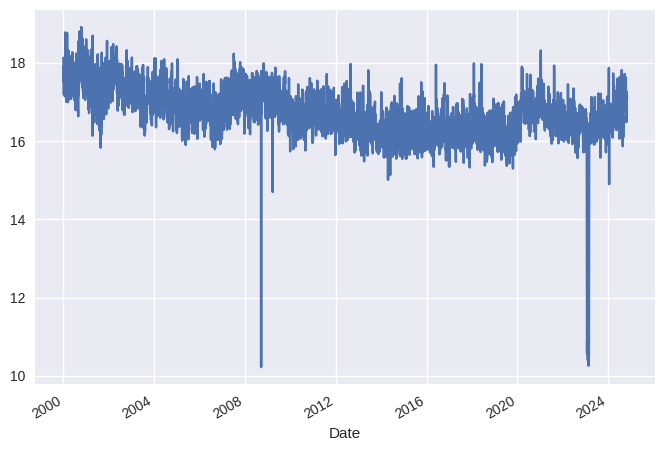

In [16]:
np.log(df.volume).plot()

In [17]:
df_ta = df.copy()

#np.where(df_ta.eom_60 == df_ta.eom_60.min())
df_ta = df_ta[(df_ta.index !=  '2008-09-18')]

In [19]:
import warnings
warnings.filterwarnings('ignore')


start = 10
end = 120
lookback = 5

for period in range(start, end, lookback):
    df_ta = get_ta_momentum(df_ta, period)
    df_ta = get_ta_volatility(df_ta, period)
    df_ta = get_ta_volume(df_ta, period)
    df_ta = get_ta_trend(df_ta, period)

In [ ]:
#df_ta_ori = df_ta.copy(deep=True)

In [20]:
df_ta = df_ta.dropna()
uns_list = get_unstable_list(df_ta)  # want to identify which ta's are unstable
                                         # STATISTICALLY UNSTABLE

### a couple of notes on `mta.get_unstable_list`

- Q: fractional integration? very much mathematical?
- Q: what do I need to understand?
  - Fractional Integration: just write off very small fraction of information, however, to make date stable

- Q: stable? you may apply just routine statistical analysis

In [ ]:
#uns_list

In [21]:
#df_ta[uns_list].div(df_ta.open)
df_ta[uns_list[4:]] = df_ta[uns_list[4:]].values / df_ta.open.values.reshape(-1,1)

In [22]:
uns_list2 = get_unstable_list(df_ta)
print(uns_list2)

['close', 'high', 'low', 'open']


<Axes: xlabel='Date'>

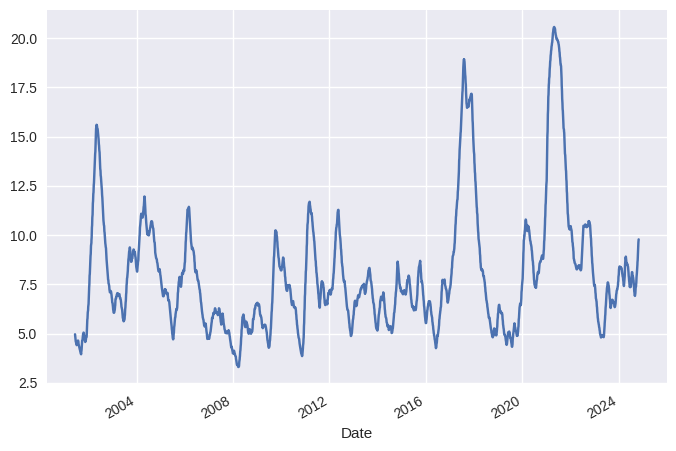

In [23]:
df_ta.adx_95.plot()  # with eyeball it looks ok

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
df_ta.iloc[int(df_ta.shape[0] * 0.8), :]
# train_test_split(df_ta, test_size=0.2)

,2020-02-06 00:00:00+00:00
close,6.110000e+04
high,6.110000e+04
low,5.970000e+04
open,6.010000e+04
volume,1.472716e+07
...,...
dmiPos_115,2.985633e+01
dmiNeg_115,2.214361e+01
adx_115,8.059145e+00
icmBase_115,8.797837e-01


In [26]:
df_ta['y_predict'] = np.where(df_ta.close.diff() >0, 1, -1)
# df_ta['y_predict] = df_ta.close.apply(lambda x: [1,-1][x.diff()<0])

In [27]:
df_ta.groupby(['y_predict']).count()

,close,high,low,open,volume,rsi_10,roc_10,cmo_10,wr_10,bbh_10,...,wma_115,trix_115,cci_115,dpo_115,kst_115,dmiPos_115,dmiNeg_115,adx_115,icmBase_115,icmLag_115
y_predict,,,,,,,,,,,,,,,,,,,,,
-1,2935,2935,2935,2935,2935,2935,2935,2935,2935,2935,...,2935,2935,2935,2935,2935,2935,2935,2935,2935,2935
1,2812,2812,2812,2812,2812,2812,2812,2812,2812,2812,...,2812,2812,2812,2812,2812,2812,2812,2812,2812,2812


In [28]:
df_ta_only = df_ta.iloc[:, 5:-1]

In [ ]:
df_ta_only.columns

Index(['rsi_10', 'roc_10', 'cmo_10', 'wr_10', 'bbh_10', 'bbl_10', 'bbp_10',
       'atr_10', 'cmf_10', 'mfi_10',
       ...
       'wma_115', 'trix_115', 'cci_115', 'dpo_115', 'kst_115', 'dmiPos_115',
       'dmiNeg_115', 'adx_115', 'icmBase_115', 'icmLag_115'],
      dtype='object', length=550)

In [29]:
split  = '2022-11-01'
X_train = df_ta_only[:split]
y_train = df_ta.loc[:split, 'y_predict']

X_test = df_ta_only[split:]
y_test = df_ta.loc[split:, 'y_predict']


In [30]:
sc = StandardScaler()
sc.fit(X_train)

StandardScaler()

In [31]:
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.fit_transform(X_test)

## Tree model

In [32]:
from sklearn.tree import DecisionTreeClassifier

clf_tr = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)

clf_tr.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)

In [33]:
yhat = clf_tr.predict(X_test)

In [34]:
from sklearn.metrics import classification_report, accuracy_score

accuracy_score(y_test, yhat) # np.sum(y == y_hat)/len(y)
#classification_report(y_test, yhat)

0.8077709611451943

In [35]:
idx_tr = np.argsort(clf_tr.feature_importances_)[::-1]
ta_import_list =(df_ta_only.columns)[idx_tr]

In [36]:
# to find our original hypothesis testing:
# to enhance predictable power, which PERIOD and
# which TAs shoud we focus on?

ta_frequency_lst(ta_import_list)


(Counter({'eom': 22,
          'bbp': 22,
          'wr': 22,
          'wma': 22,
          'bbh': 22,
          'bbl': 22,
          'sma': 22,
          'ema': 22,
          'smao': 21,
          'icmlag': 21,
          'dpo': 22,
          'adx': 22,
          'dmineg': 21,
          'icmbase': 21,
          'cmf': 22,
          'mfi': 22,
          'icmLag': 1,
          'atr': 22,
          'fi': 22,
          'trix': 22,
          'cci': 22,
          'roc': 22,
          'kst': 22,
          'dmipos': 21,
          'rsi': 22,
          'cmo': 22,
          'smaO': 1,
          'dmiPos': 1,
          'dmiNeg': 1,
          'icmBase': 1}),
 Counter({'110': 25,
          '10': 25,
          '15': 25,
          '25': 25,
          '45': 25,
          '115': 25,
          '100': 25,
          '105': 25,
          '70': 25,
          '55': 25,
          '50': 25,
          '40': 25,
          '35': 25,
          '60': 25,
          '20': 25,
          '30': 25,
          '95': 25,
  

In [37]:
# top 5

ta_import_list[:5]

Index(['eom_110', 'bbp_10', 'wr_10', 'wma_10', 'bbh_10'], dtype='object')

### What is eom?

$$
\begin{align}
\text{distance} &=
   \Big(\frac
            {p^{\text{high}}-p^{\text{low}}}
            {2}
            -
        \frac
           {p^{\text{pre\_high}}-p^{\text{pre\_low}}}
           {2}   
   \Big) \\
\text{Box\_Ratio} &= \frac{\frac{V}{\text{scale}}}{p^{\text{high}- p^{\text{low}}}} \\
\text{eom}_t &= \frac{\text{distance}}{\text{BoxRatio}} \\
   \text{eom(10)} &= \text{eom.rolling(10).mean()}
\end{align}   
$$

In [38]:
np.sort(clf_tr.feature_importances_)[::-1][:5]

array([0.59064577, 0.14201071, 0.06930111, 0.06680074, 0.0482299 ])

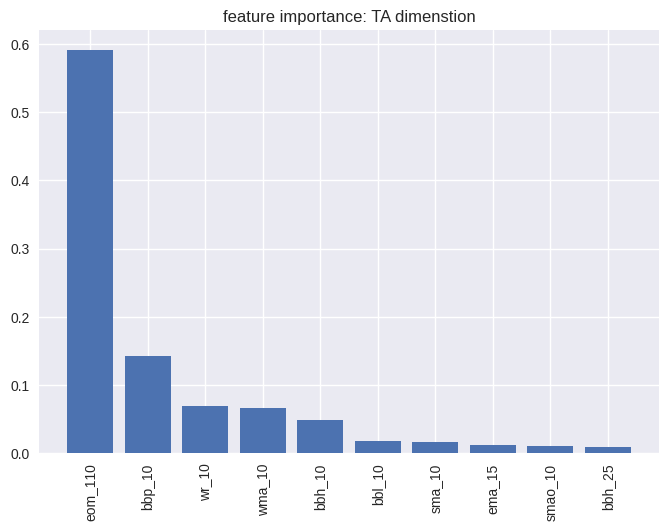

In [39]:
plt.bar(ta_import_list.tolist()[:10], height =clf_tr.feature_importances_[idx_tr][:10])
plt.xticks(ta_import_list.tolist()[:10], rotation=90)
plt.title('feature importance: TA dimenstion');

<Axes: >

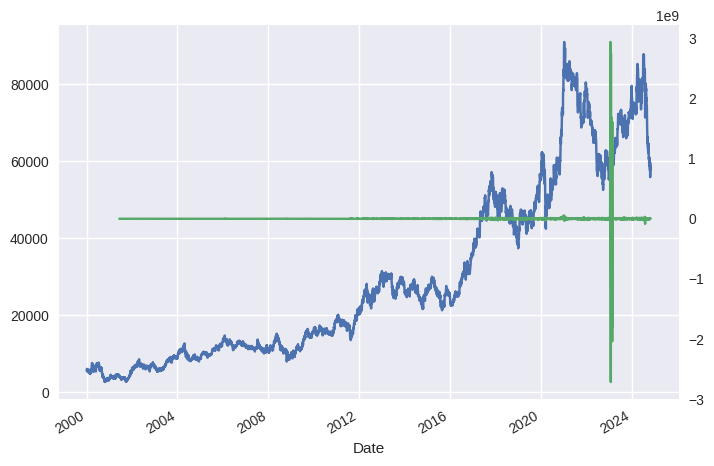

In [40]:
ax  =df.close.plot()
df_ta.eom_40.plot(secondary_y=True, ax=ax)

## Is eom is possible strategy?

In [41]:
clf_tr.feature_importances_[idx_tr][:5]

array([0.59064577, 0.14201071, 0.06930111, 0.06680074, 0.0482299 ])

In [42]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(clf_tr, prefit=True, threshold=0.03)
X_train_selector = selector.transform(X_train)
X_train_selector.shape

(5259, 5)

In [43]:
X_test_selector = selector.transform(X_test)

In [44]:
clf_tr_best = clf_tr.fit(X_train_selector, y_train)
yhat_2 = clf_tr_best.predict(X_test_selector)

In [45]:
len(yhat_2)

489

In [46]:
accuracy_score(yhat_2, y_test)

0.8016359918200409

#### Using 4 features as a strategy

In [47]:
df_st = pd.DataFrame().assign(ret=df.close.pct_change())

In [48]:
df_st = df_st.shift(-1)   # return on signal
df_st = df_st[-len(yhat_2):]
df_st = df_st.assign(yhat = yhat_2.tolist())
df_st = df_st.dropna()

In [49]:
df_st['st_ret'] = df_st.ret * df_st.yhat

In [50]:
(df_st.st_ret + 1.0).cumprod().mean()

0.6028441092332031

Text(0.5, 1.0, 'cumulative return over test period: 4 features')

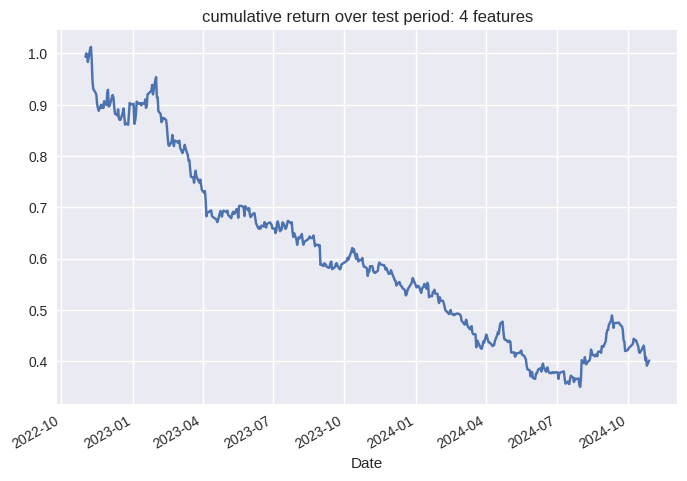

In [51]:
(df_st.st_ret + 1.0).cumprod().plot()
plt.title("cumulative return over test period: 4 features")

### Is it the same as using all TA features?

In [52]:
df_st['yhat_ori'] = clf_tr.predict(X_test_selector)[-len(df_st):]

In [53]:
(1.0 +df_st.ret *df_st.yhat_ori).cumprod().mean()

23.72710225830824

Text(0.5, 1.0, 'cumulative return over test period: All TAs')

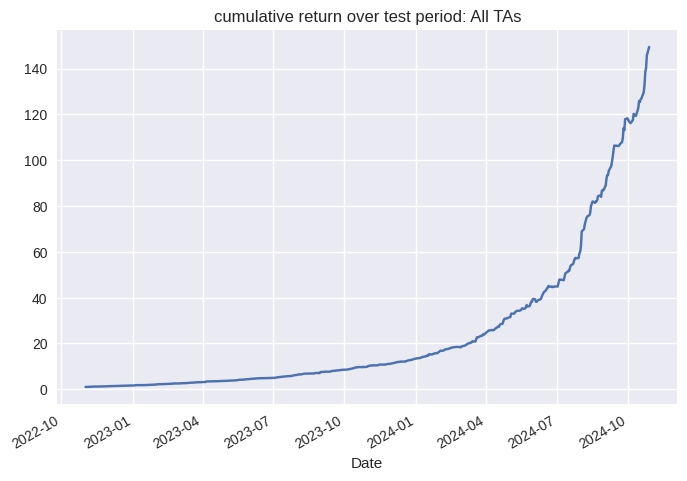

In [54]:
(1.0 +df_st.ret *df_st.yhat_ori).cumprod().plot()
plt.title("cumulative return over test period: All TAs")

In [55]:
accuracy_score(df_st.yhat, df_st.yhat_ori)

0.569672131147541

# Reference from here

## Why this happen?

- overall average is an indicator for reference spotting feture variables
- feature importances are time varying

## time varying feature?

In [56]:

X = df_ta.iloc[:, :-1]
y = df_ta.iloc[:, -1]

In [57]:
X.head()

,close,high,low,open,volume,rsi_10,roc_10,cmo_10,wr_10,bbh_10,...,wma_115,trix_115,cci_115,dpo_115,kst_115,dmiPos_115,dmiNeg_115,adx_115,icmBase_115,icmLag_115
Date,,,,,,,,,,,,,,,,,,,,,
2001-06-11 00:00:00+00:00,4280.0,4380.0,4280.0,4330.0,24680000,46.255689,-3.603604,-11.594,-60.000000,1.074854,...,0.973500,-0.134149,52.197651,-190.434783,42.834585,28.388602,27.463748,4.364984,0.922633,0.872979
2001-06-12 00:00:00+00:00,4220.0,4300.0,4210.0,4220.0,24195000,44.032567,-5.168539,-16.084,-70.000000,1.096765,...,0.999446,-0.132677,35.587418,-285.652174,31.778890,28.290973,27.636778,4.337199,0.946682,0.857820
2001-06-13 00:00:00+00:00,4280.0,4310.0,4200.0,4300.0,23645000,46.869813,-7.758621,-27.692,-51.020408,1.047703,...,0.981631,-0.131210,39.137735,-272.521739,18.666214,28.171523,27.520090,4.309656,0.929070,0.811628
2001-06-14 00:00:00+00:00,4230.0,4310.0,4200.0,4270.0,27840000,44.768409,-5.369128,-20.339,-59.574468,1.040351,...,0.989083,-0.129755,34.358471,-228.347826,5.321843,28.052042,27.403372,4.282352,0.935597,0.833724
2001-06-15 00:00:00+00:00,4190.0,4200.0,4120.0,4190.0,40870000,43.052622,-1.179245,-5.051,-68.085106,1.059937,...,1.008345,-0.128316,15.540956,-124.086957,-3.701156,27.932536,27.596459,4.250377,0.953461,0.842482


In [58]:
uns_list_sim = get_unstable_list(X.iloc[:, 4:])

In [ ]:
lookback = 1000
feature_name1  = []
feature_name2  = []
feature_name3  = []
feature_imp1  = []
feature_imp2  = []
feature_imp3 = []

for i in range(len(X)- lookback):
#for i in range(2):
    XX = X.iloc[:lookback+i, 4:]
    yy = y[:lookback+i]

    uns_list_sim = get_unstable_list(XX)
    XX[uns_list_sim] = XX[uns_list_sim].values / X.iloc[:lookback+i, 0].values.reshape(-1,1)


    sc_sim = StandardScaler()
    XX_sc = sc_sim.fit_transform(XX)

    clf_sim = DecisionTreeClassifier(max_depth=5,             min_samples_leaf=10).fit(XX_sc, yy)

    idx_sim = np.argsort(clf_sim.feature_importances_)[::-1]
    feature_name1.append((XX.columns)[idx_sim][0])
    feature_name2.append((XX.columns)[idx_sim][1])
    feature_name3.append((XX.columns)[idx_sim][2])

    feature_imp1.append((clf_sim.feature_importances_)[idx_sim][0])
    feature_imp2.append((clf_sim.feature_importances_)[idx_sim][1])
    feature_imp3.append((clf_sim.feature_importances_)[idx_sim][2])

In [ ]:
pd.Series(feature_name1).to_csv("feature_name1.csv")
pd.Series(feature_name2).to_csv("feature_name2.csv")
pd.Series(feature_name3).to_csv("feature_name3.csv")

pd.Series(feature_imp1).to_csv("feature_imp1.csv")
pd.Series(feature_imp2).to_csv("feature_imp2.csv")
pd.Series(feature_imp3).to_csv("feature_imp3.csv")

In [59]:
df['feature_name1'] = [np.nan] * (len(df)-len(feature_name1)) + feature_name1
df['feature_imp1'] = [np.nan] * (len(df)-len(feature_imp1)) + feature_imp1

NameError: name 'feature_name1' is not defined

In [ ]:
df['feature_name2'] = [np.nan] * (len(df)-len(feature_name2)) + feature_name2
df['feature_imp2'] = [np.nan] * (len(df)-len(feature_imp2)) + feature_imp2

In [ ]:
df['feature_name3'] = [np.nan] * (len(df)-len(feature_name3)) + feature_name3
df['feature_imp3'] = [np.nan] * (len(df)-len(feature_imp3)) + feature_imp3

In [ ]:
mta.ta_frequency_lst(feature_name1)

(Counter({'eom': 3895}),
 Counter({'45': 174,
          '15': 178,
          '25': 175,
          '90': 176,
          '20': 183,
          '10': 156,
          '65': 207,
          '35': 167,
          '50': 196,
          '75': 172,
          '60': 174,
          '105': 186,
          '30': 173,
          '40': 136,
          '70': 178,
          '80': 148,
          '115': 202,
          '55': 194,
          '95': 166,
          '100': 180,
          '110': 201,
          '85': 173}))

In [ ]:
mta.ta_frequency_lst(feature_name2)

(Counter({'bbp': 3611, 'wr': 284}), Counter({'10': 3895}))

In [ ]:
mta.ta_frequency_lst(feature_name3)

(Counter({'cci': 1183,
          'wr': 2015,
          'eom': 154,
          'atr': 3,
          'bbp': 284,
          'dmineg': 256}),
 Counter({'15': 137,
          '10': 3617,
          '30': 9,
          '70': 11,
          '110': 8,
          '50': 11,
          '80': 10,
          '35': 8,
          '100': 2,
          '40': 5,
          '45': 7,
          '20': 9,
          '65': 7,
          '25': 5,
          '55': 7,
          '105': 5,
          '85': 9,
          '75': 5,
          '95': 3,
          '60': 12,
          '90': 4,
          '115': 4}))

In [ ]:
df_ta.columns

Index(['open', 'high', 'low', 'close', 'volume', 'rsi_10', 'roc_10', 'cmo_10',
       'wr_10', 'bbh_10',
       ...
       'trix_115', 'cci_115', 'dpo_115', 'kst_115', 'dmiPos_115', 'dmiNeg_115',
       'adx_115', 'icmBase_115', 'icmLag_115', 'y_predict'],
      dtype='object', length=556)

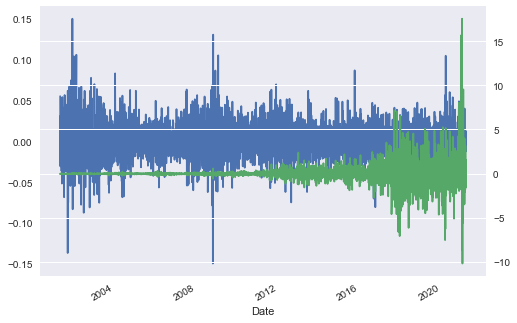

In [ ]:
ax  = df_ta.close.pct_change().plot()
df_ta.eom_65.sub(df_ta.eom_65.mean()).div(df_ta.eom_65.std()).plot(secondary_y=True, ax=ax)

Text(0.5, 1.0, 'Feature importance of EOM')

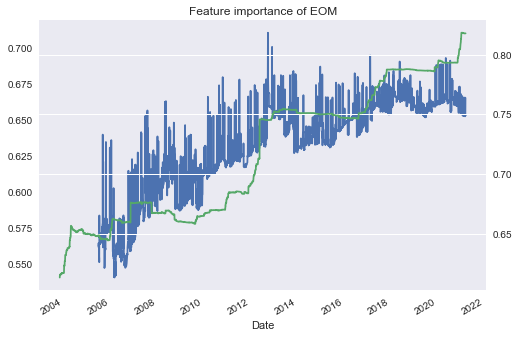

In [ ]:
ax = df['feature_imp1'].plot()
df['Hc'].plot(secondary_y=True, ax=ax)
plt.title('Feature importance of EOM vs. Hurst')

## Hurst Exponent

- H = 0.5: Brownian motion (Radom walk)
- H < 0.5: Mean reversion
- H > 0.5: persistent

- based on autocorrelation function: $H = 1 - \frac{\alpha}{2}$
$$
\rho(k) = c \cdot k^{-\alpha}
$$

where $c$: constant, $k$: lag, $\alpha$: persistency measure
- $0 < \alpha < 0.5$: persistent
- $\alpha=1$ : random walk
-  $1<\alpha <2$: mean reversion


- Hurst strategy see [Hurst Exponent and Trading Signals
Derived from Market Time Series, Kroha and Skoula, 2019](https://www.scitepress.org/Papers/2018/66670/66670.pdf)

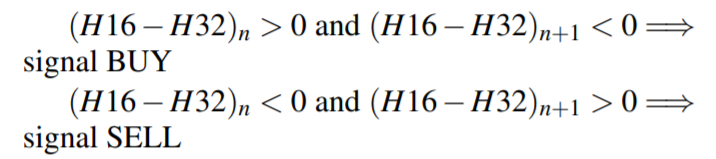

In [ ]:
from IPython.display import Image
Image("G:/python/images/hurst_strategy.PNG")

In [ ]:
from hurst import compute_Hc

In [ ]:
H, _, __ =compute_Hc(df.close, kind='price', simplified=True)

# I don't know data for?

In [ ]:
# Hc_lst = pd.DataFrame(index=df.index)
Hc_lst = []
lookback = 1000

for i in range(len(df)-lookback):
    tmp  = compute_Hc(df[:1000+i].close, kind='price')[0]
    Hc_lst.append(tmp)


In [ ]:
df['Hc'] = [np.nan] * (lookback) + Hc_lst

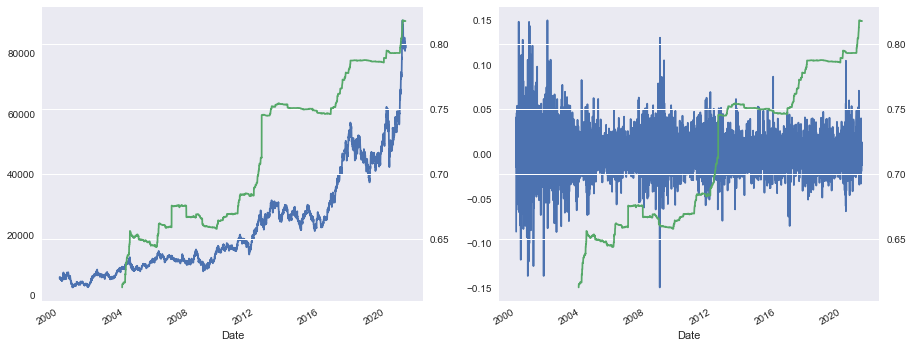

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(15,6))
df.close.plot(ax=axs[0])
df.Hc.plot(secondary_y=True, ax=axs[0])
#axs[0].right_ax.axhline(0, ls='--' , c='r')
#axs[0].right_ax.axhline(0.5, ls='--' , c='r')

df.close.pct_change().plot(ax=axs[1])
df.Hc.plot(secondary_y=True, ax=axs[1]);


In [ ]:
df_all = df.merge(df_ta.iloc[:, 5], right_index=True, left_index=True)

In [ ]:
df_all.to_csv('df_all.csv')

In [ ]:
# new data

n_data = df_all[['close', 'feature_imp1', 'Hc']]



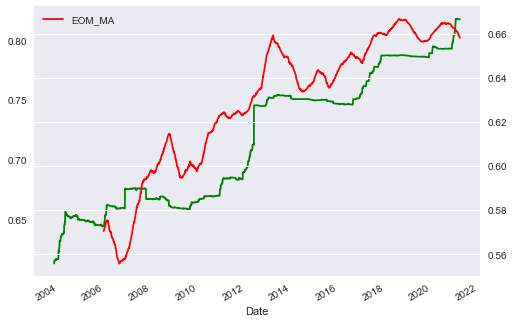

In [ ]:
ax =n_data.Hc.plot(c='g', label='Hurst coef')
n_data.feature_imp1.rolling(120).mean().plot(secondary_y=True, ax=ax, c='r', label='EOM_MA')
plt.legend()

In [10]:
!pip install ta

import pandas as pd
import numpy as np
from ta import momentum, trend, volatility, volume

def get_labels_peak_trough(df, period=13):

    assert isinstance(df, pd.DataFrame)
    df.columns = [x.lower() for x in df.columns]

    lag = (period) / 2 if period % 2==0 else (period+1)/2
    lag = int(lag)

    tmp = df[["close"]]
    tmp['min_11'] = tmp.close.rolling(lag).min()
    tmp['fmin_11'] = tmp.close.shift(-lag).rolling(lag).min()
    tmp['max_11'] = tmp.close.rolling(lag).max()
    tmp['fmax_11'] = tmp.close.shift(-lag).rolling(lag).max()
    tmp = tmp.dropna()

    idx1= (tmp.close==tmp.min_11) & (tmp.min_11<=tmp.fmin_11)  # buy=1
    idx2 = (tmp.close==tmp.max_11) & (tmp.max_11>=tmp.fmax_11) # sell=0  hold=2
    idx3 = (~idx1)&(~idx2)
#    print(np.sum(idx1)/len(tmp), np.sum(idx2)/len(tmp))
    idx = (idx1 * 1 + idx2*0 + idx3*2).to_frame()
    idx.columns =['position']
    tmp = pd.merge(df, idx, right_index=True, left_index=True)

    return tmp

def get_ta_momentum(df, period=13):
    # assert error
    assert isinstance(df, pd.DataFrame)
    df.columns = [x.lower() for x in df.columns]

    if type(period)==int:
        df['rsi_'+str(period)] = momentum.rsi(df.close, period)
        df['roc_'+str(period)] = momentum.roc(df.close, period)
        df['cmo_'+str(period)] = get_cmo(df, period=period)
        df['wr_'+str(period)]  = momentum.williams_r(df.high, df.low, df.close, period)

    else:
        periods = period

    # if spatial nearness is in among ta rather than among tas, then
    # combine all procedure with one-loop

        for period in periods:
            df['rsi_'+str(period)] = momentum.rsi(df.close, period)
        for period in periods:
            df['roc_'+str(period)] = momentum.roc(df.close, period)
        for period in periods:
            df['cmo_'+str(period)] = get_cmo(df.close, period=period)
        for period in periods:
            df['wr_'+str(period)]  = momentum.williams_r(df.high, df.low, df.close, period)

    return df

def get_ta_volume(df, period=13):
    # assert error
    assert isinstance(df, pd.DataFrame)
    df.columns = [x.lower() for x in df.columns]

    if type(period)==int:
        df['cmf_'+str(period)] = volume.chaikin_money_flow(df.high, df.low, df.close, df.volume, period)
        df['mfi_'+str(period)] = volume.money_flow_index(df.high, df.low, df.close, df.volume, period)
        df['fi_'+ str(period)] = volume.force_index(df.close, df.volume, period)
        df['eom_'+str(period)] = volume.ease_of_movement(df.high, df.low, df.volume, period)

    else:
        periods = period

    # if spatial nearness is in among ta rather than among tas, then
    # combine all procedure with one-loop

        for period in periods:
            df['cmf_'+str(period)] = volume.chaikin_money_flow(df.high, df.low, df.close, df.volume, period)
        for period in periods:
            df['mfi_'+str(period)] = volume.money_flow_index(df.high, df.low, df.close, df.volume, period)
        for period in periods:
            df['fi_'+ str(period)] = volume.force_index(df.close, df.volume, period)
        for period in periods:
            df['eom_'+str(period)] = volume.ease_of_movement(df.high, df.low, df.volume, period)

    return df


def get_ta_volatility(df, period=13):
    # assert error
    assert isinstance(df, pd.DataFrame)
    df.columns = [x.lower() for x in df.columns]

    if type(period)==int:
        df['bbh_'+str(period)] = volatility.bollinger_hband(df.close, period)
        df['bbl_'+str(period)] = volatility.bollinger_lband(df.close, period)
        df['bbp_'+str(period)] = volatility.bollinger_pband(df.close, period)
        df['atr_'+str(period)] = volatility.average_true_range(df.high, df.low, df.close, period)

    else:
        periods = period

    # if spatial nearness is in among ta rather than among tas, then
    # combine all procedure with one-loop

        for period in periods:
            df['bbh_'+str(period)] = volatility.bollinger_hband(df.close, period)
        for period in periods:
            df['bbl_'+str(period)] = volatility.bollinger_lband(df.close, period)
        for period in periods:
            df['bbp_'+str(period)] = volatility.bollinger_pband(df.close, period)
        for period in periods:
            df['atr_'+str(period)] = volatility.average_true_range(df.high, df.low, df.close, period)

    return df

def get_ta_trend(df, period=13):
    # assert error
    assert isinstance(df, pd.DataFrame)
    df.columns = [x.lower() for x in df.columns]

    if type(period)==int:
        df['sma_'+str(period)]  = trend.sma_indicator(df.close, period)
        df['smaO_'+str(period)] = trend.sma_indicator(df.open, period)
        df['ema_'+str(period)]  = trend.ema_indicator(df.close, period)
        df['wma_'+str(period)] = trend.wma_indicator(df.close, period)
        ### below: relative number matter
        df['trix_'+str(period)] = trend.trix(df.close, period)
        df['cci_'+str(period)] = trend.cci(df.high, df.low, df.close, period)
        df['dpo_'+str(period)] = trend.dpo(df.close, period)  # trend occilator
        df['kst_'+str(period)] = trend.kst(df.close, period)  # know sure thing
        df['dmiPos_'+str(period)] = trend.adx_pos(df.high, df.low, df.close, period)  # dmi: directional movement index
        df['dmiNeg_'+str(period)] = trend.adx_neg(df.high, df.low, df.close, period)  # dmi: directional movement index
        df['adx_'+str(period)] = trend.adx(df.high, df.low, df.close, period)  # adx:strength of trend

        # df['icmBase_'+str(period)] = trend.ichimoku_base_line(df.high, df.low, period, int(period*2.89))
        # df['icmLag_'+str(int(period*2.89))] = df.close.shift(int(period*2.89))

        df['icmBase_'+str(period)] = trend.ichimoku_base_line(df.high, df.low, period, int(period))
        df['icmLag_'+str(int(period))] = df.close.shift(int(period))

    else:
        periods = period

    # if spatial nearness is in among ta rather than among tas, then
    # combine all procedure with one-loop

        for period in periods:
            df['sma_'+str(period)]  = trend.sma_indicator(df.close, period)
        for period in periods:
            df['smaO_'+str(period)] = trend.sma_indicator(df.open, period)
        for period in periods:
            df['ema_'+str(period)]  = trend.ema_indicator(df.close, period)
        for period in periods:
            df['wma_'+str(period)] = trend.wma_indicator(df.close, period)
        for period in periods:
            df['trix_'+str(period)] = trend.trix(df.close, period)
        for period in periods:
            df['cci_'+str(period)] = trend.cci(df.high, df.low, df.close, period)
        for period in periods:
            df['dpo_'+str(period)] = trend.dpo(df.close, period)  # trend occilator
        for period in periods:
            df['kst_'+str(period)] = trend.kst(df.close, period)  # know sure thing
        for period in periods:
            df['dmiPos_'+str(period)] = trend.adx_pos(df.high, df.low, df.close, period)  # dmi: directional movement index
        for period in periods:
            df['dmiNeg_'+str(period)] = trend.adx_neg(df.high, df.low, df.close, period)  # dmi: directional movement index
        for period in periods:
            df['adx_'+str(period)] = trend.adx(df.high, df.low, df.close, period)  # adx:strength of trend
        for period in periods:
            df['dpo_'+str(period)] = trend.dpo(df.close, period)  # trend occilator
        # for period in periods:
        #     df['icmBase_'+str(period)] = trend.ichimoku_base_line(df.high, df.low, period, int(period*2.89))
        # for period in periods:
        #     df['icmLag_'+str(int(period*2.89))] = df.close.shift(int(period*2.89))

        for period in periods:
            df['icmBase_'+str(period)] = trend.ichimoku_base_line(df.high, df.low, period, int(period))
        for period in periods:
            df['icmLag_'+str(int(period))] = df.close.shift(int(period))

    return df

def calculate_CMO(series):
    sum_gains = series[series >= 0].sum()
    sum_losses = np.abs(series[series < 0].sum())
    cmo = 100 * ((sum_gains - sum_losses) / (sum_gains + sum_losses))

    return np.round(cmo, 3)

def get_cmo(df, period=13):
    #tmp = df.close.diff().rolling(period).apply(calculate_CMO, args=(period,), raw=True)

    tmp = df.close.diff().rolling(period).apply(calculate_CMO, raw=True)
    return tmp


def get_dmi(df, intervals):
    tmp = pd.DataFrame([])
    for period in intervals:
        tmp['adx_pos'+str(period)]=adx_pos(df.High, df.Low, df.Close, period)
        tmp['adx_neg'+str(period)]=adx_neg(df.High, df.Low, df.Close, period)
        tmp['adx'+str(period)] = adx(df.High, df.Low, df.Close, period)

    return tmp

def get_ibr(df):

    ibr = (df.close - df.low) / (df.high - df.low)

    return ibr

from collections import Counter

def ta_frequency_lst(lst):
    """
    lst: ta names
    """
    tmp = lst.copy()
    tmp_s = [x.split('_')[0] for x in tmp ]
    tmp_p = [x.split('_')[1] for x in tmp if '_' in x]

    return Counter(tmp_s), Counter(tmp_p)

from statsmodels.tsa.stattools import adfuller

def get_unstable_list(df):

    lst = []

    i = 0
    for i in range(0, df.shape[1]):
        try:
            tmp = adfuller(df.iloc[:, i], maxlag=1, regression='c', autolag=None)
            if tmp[0] > tmp[4]['5%']:
                lst.append(df.columns[i])
        except:
             pass

    return lst

import numpy as np
def remove_nan_zero(df):

    """
    Input:
        df: data frame
    Output:
        df: remove [np.inf, -np.inf, 0]
    """
    tmp = df.copy()
    tmp = df.replace([np.inf, -np.inf, 0], np.nan).fillna(method='bfill')

    return tmp

# momentum = [x for x in dir(ta.momentum)  if x[0].islower()]
# trend = [x for x in dir(ta.trend)  if x[0].islower()]
# volatility = [x for x in dir(ta.volatility)  if x[0].islower()]
# volume = [x for x in dir(ta.volume)  if x[0].islower()]


# ta_dict = dict(momentum=momentum, trend=trend, volatility=volatility, volume=volume)

# tmp1 = [{x:'momentum'} for x in momentum]
# tmp2 = [{x:'trend'} for x in trend]
# tmp3 = [{x:'trend'} for x in volatility]
# tmp4 = [{x:'trend'} for x in volume]

# tmp = tmp1 + tmp2 + tmp3 + tmp4

### categorical list
# momentum_lst = ['rsi', 'roc', 'cmo', 'wr']
# volume_lst = ['cmf', 'mfi', 'fi', 'eom']
# volatility_lst = ['bbh', 'bbl', 'bbp', 'atr']
# trend_lst = ['sma', 'smaO', 'ema', 'wma', 'trix', 'cci', 'dpo', 'kst', "dmiPos",
# "dmiNeg", 'adx', "icmBase", 'icmLag']



  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=000019fdf3c70404cacfd283c8642ca9973d77df879a7a1e9c346a5fea6add9c
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta
